# Mandarin Text Line Detection

### Create the bounding boxes for all text lines in an image

In [14]:

from paddleocr import TextDetection
from pathlib import Path

def run_detector(image_path: str):
    # Initialize the OCR model
    text_detector = TextDetection(
        model_name="PP-OCRv5_mobile_det",
        enable_mkldnn=False,  # prevents MKLDNN/PIR crash
        )
    
    # Run inference on image 
    result = text_detector.predict(
        input=image_path
    )

    return result

### Crop the bounding boxes

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def order_points(pts):
    """Orders points clockwise starting from top left"""
    pts = np.asarray(pts, dtype=np.float32)
    s = np.sum(pts, axis=1).reshape(-1)
    diff = np.diff(pts, axis=1).reshape(-1)
    ordered = np.zeros((4, 2), dtype=np.float32)
    ordered[0] = pts[np.argmin(s)]  # top-left
    ordered[2] = pts[np.argmax(s)]  # bottom-right
    ordered[1] = pts[np.argmin(diff)]  # top-right
    ordered[3] = pts[np.argmax(diff)]  # bottom-left
    return ordered

def crop_and_wrap(polygons, image_path: Path, show_plots=True):

    #polygons = result[0]["dt_polys"]
    #image_path = result[0]["input_path"]

    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Could not read image at {image_path}")

    # Iterate over detected polygons, order points, compute perspective transform, and warp
    text_crops = []
    for polygon_index, polygon in enumerate(polygons):
        pts = order_points(polygon)
        # Source points
        (tl, tr, br, bl) = pts

        width_a = np.linalg.norm(br - bl)
        width_b = np.linalg.norm(tr - tl)
        max_width = int(max(width_a, width_b))

        height_a = np.linalg.norm(tr - br)
        height_b = np.linalg.norm(tl - bl)
        max_height = int(max(height_a, height_b))

        if max_width <= 0 or max_height <= 0:
            continue
        
        # Destination points
        dst = np.array(
            [
                [0, 0],
                [max_width - 1, 0],
                [max_width - 1, max_height - 1],
                [0, max_height - 1],
            ],
            dtype=np.float32,
        )
        matrix = cv2.getPerspectiveTransform(pts, dst)
        warped = cv2.warpPerspective(image, matrix, (max_width, max_height))

        # Convert to Grayscale
        gray_img = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

        
        text_crops.append(gray_img)
        if show_plots:
            plt.figure(figsize=(4, 4))
            plt.imshow(gray_img, cmap="gray")
            plt.title(f"Warped crop {polygon_index}")
            plt.axis("off")
            plt.show()
    return text_crops

### Test it out

Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\adria\.paddlex\official_models\PP-OCRv5_mobile_det`.


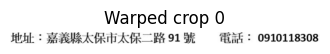

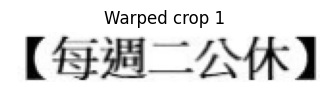

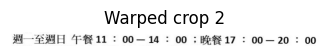

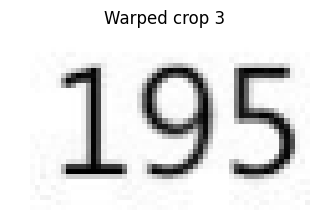

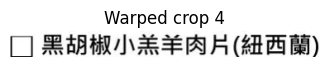

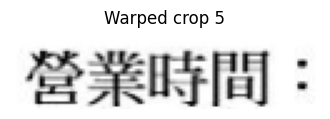

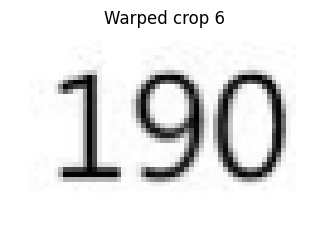

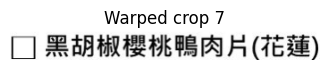

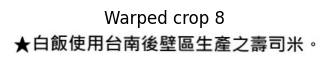

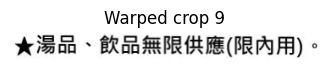

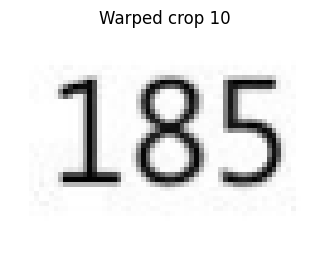

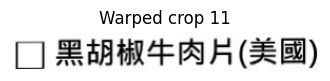

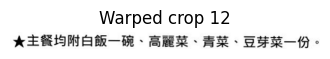

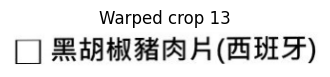

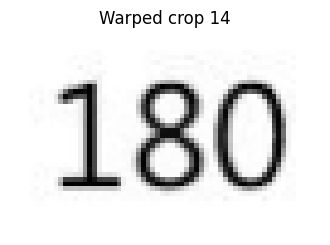

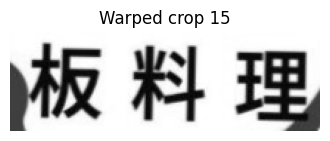

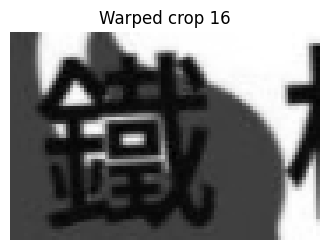

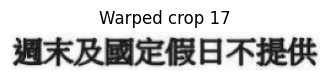

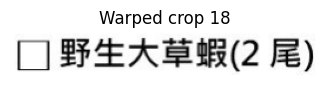

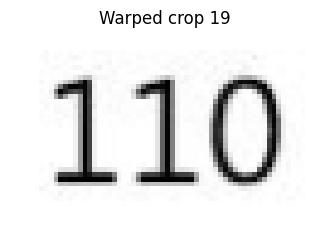

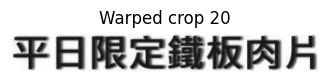

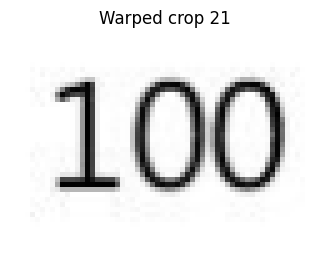

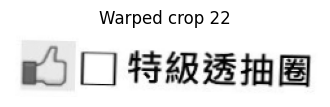

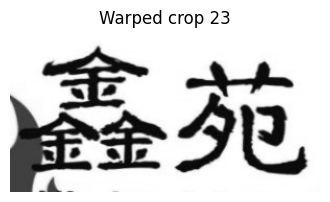

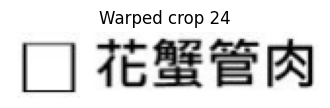

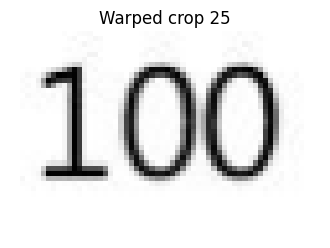

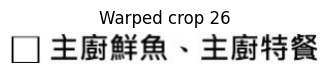

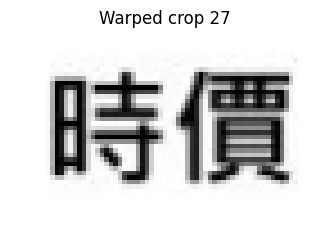

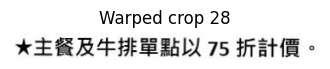

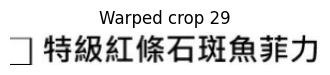

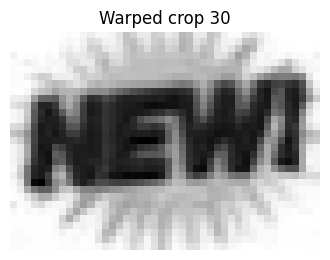

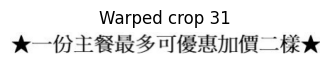

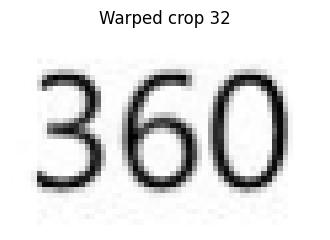

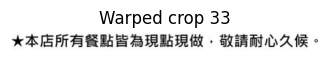

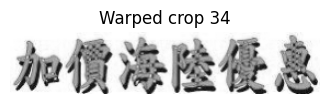

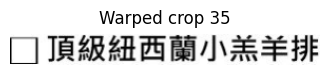

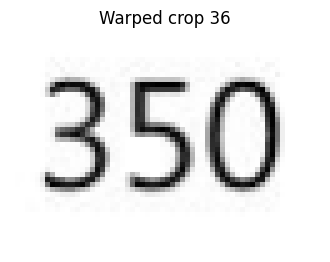

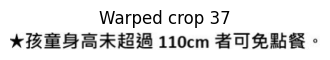

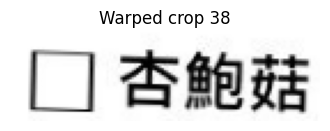

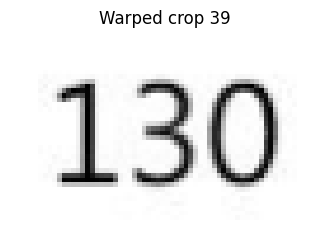

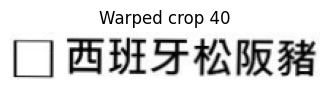

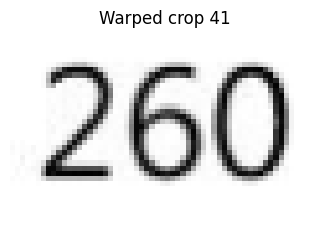

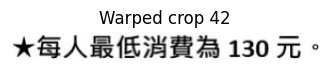

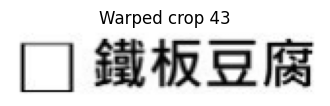

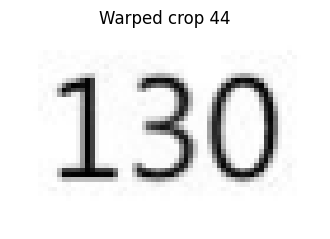

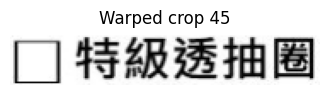

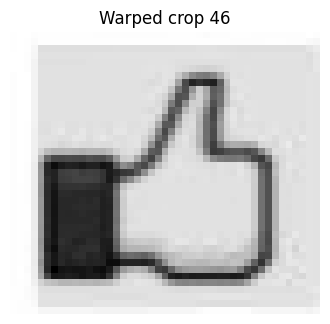

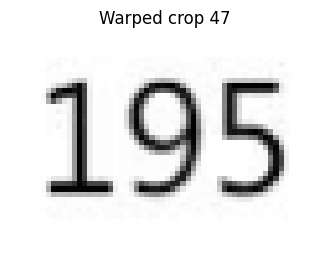

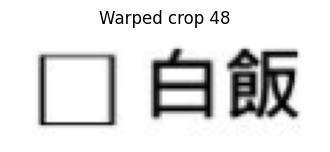

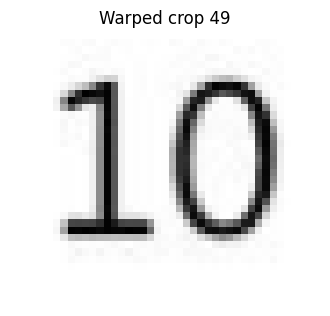

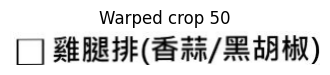

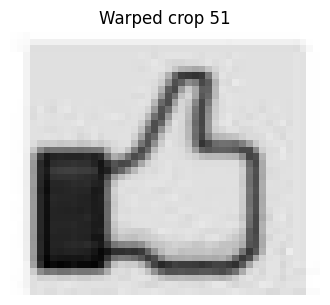

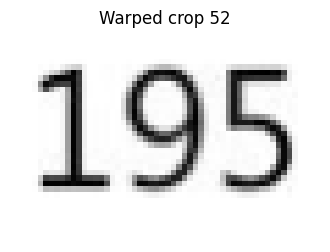

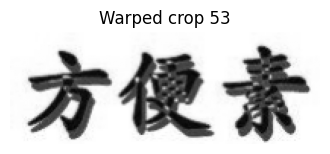

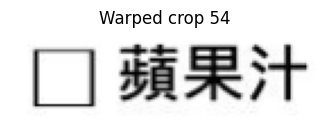

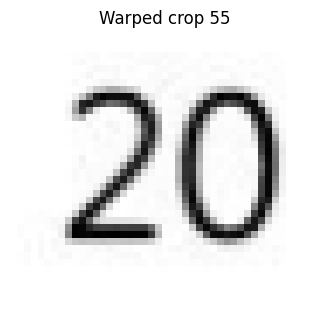

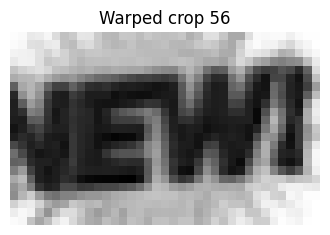

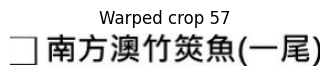

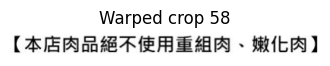

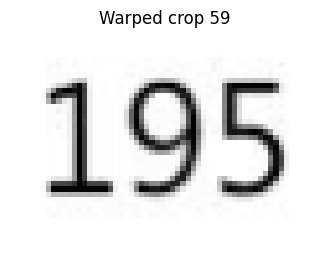

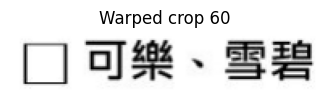

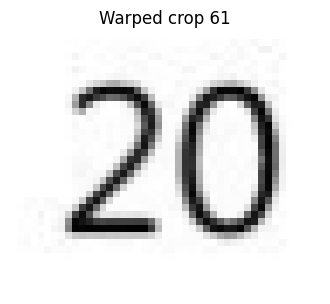

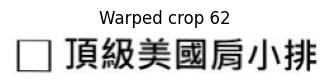

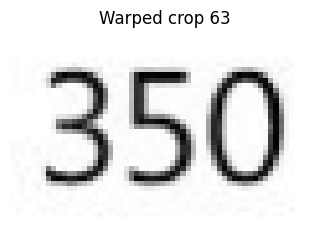

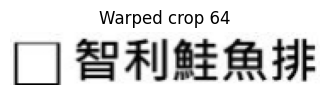

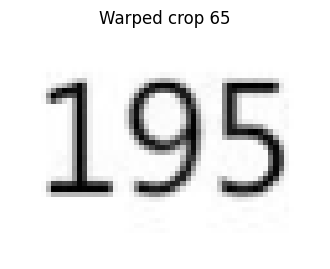

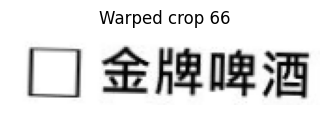

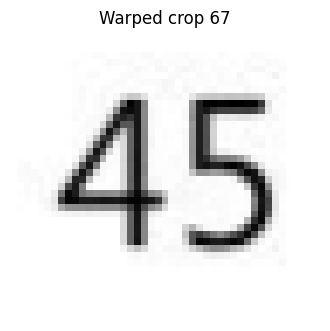

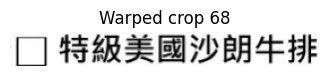

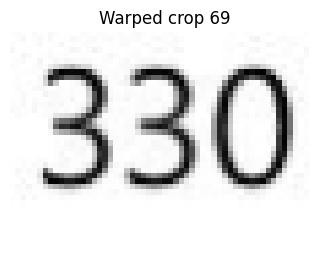

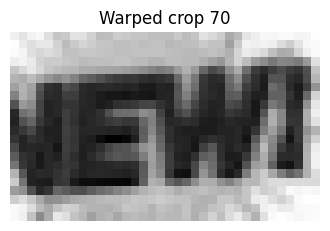

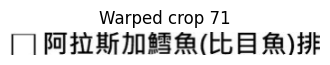

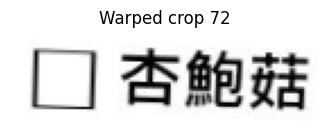

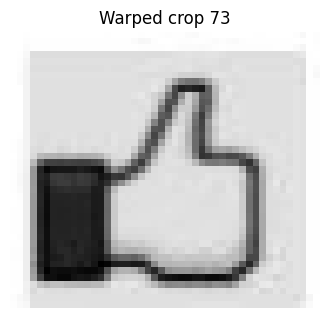

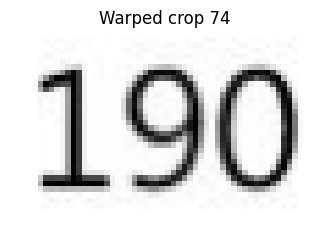

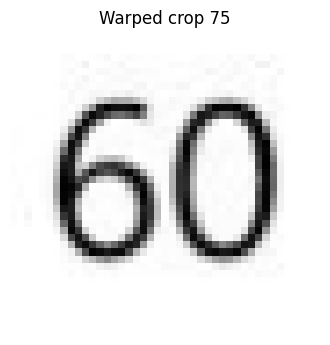

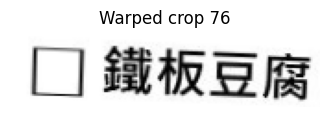

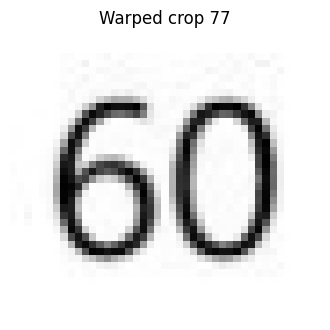

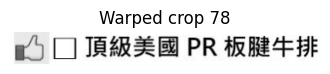

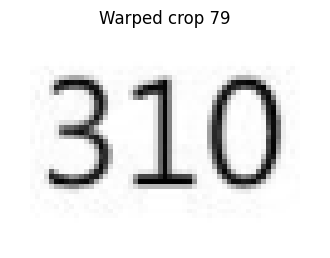

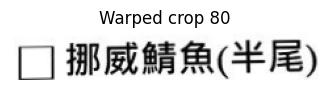

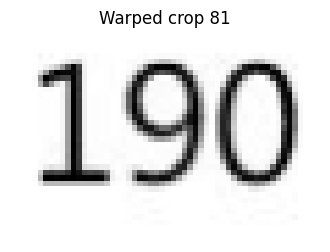

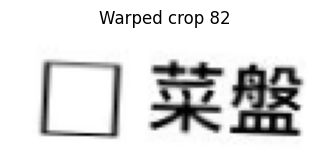

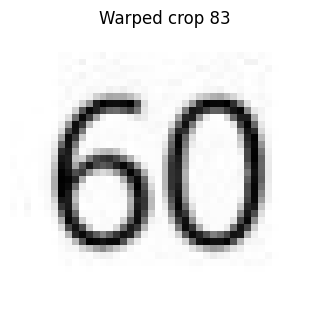

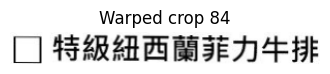

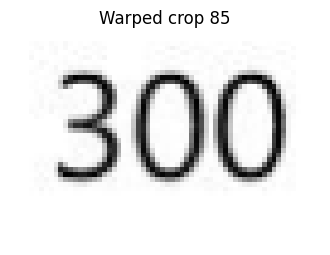

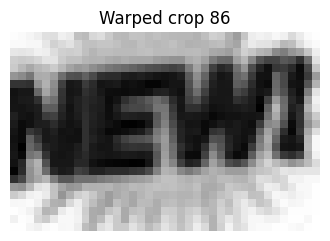

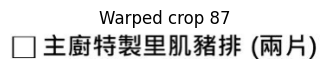

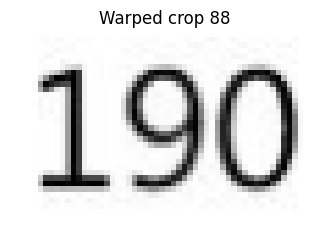

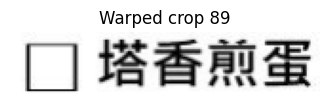

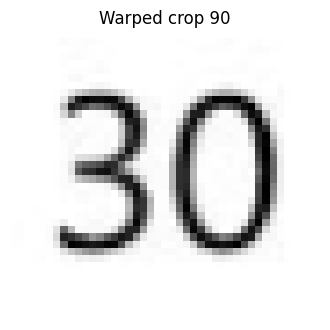

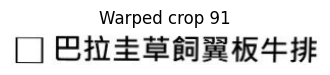

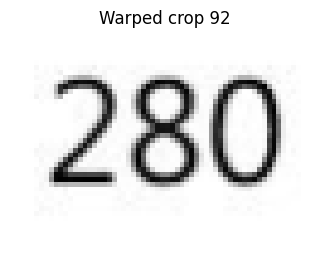

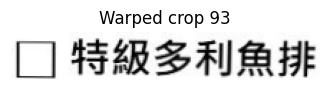

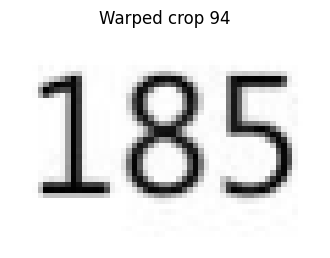

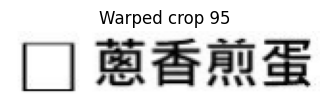

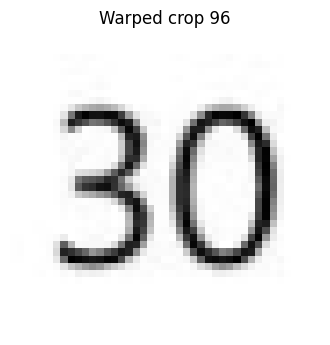

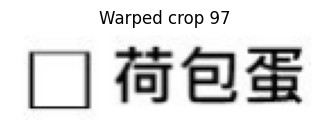

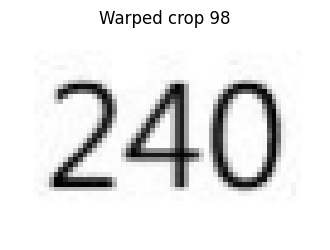

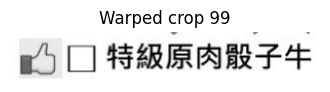

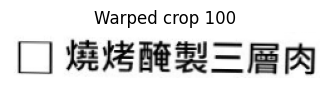

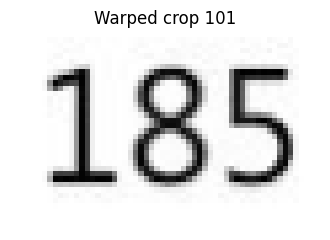

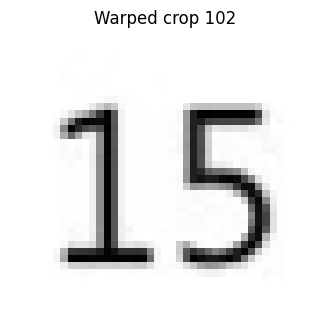

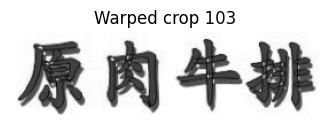

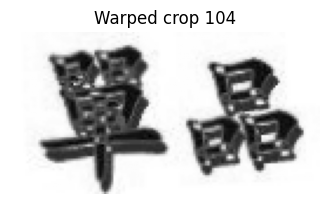

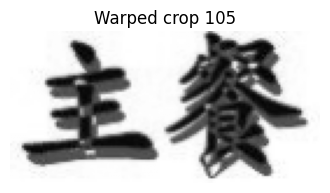

In [18]:
image_path = Path("../data/test_images/menu.jpg")

result = run_detector(str(image_path))

polygons = result[0]["dt_polys"]
crops = crop_and_wrap(polygons, image_path)